In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from functools import partial
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
from scipy.optimize import differential_evolution, least_squares
from matplotlib.patches import ConnectionPatch

In [17]:
#数据准备
dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=44
right_index=101
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
print(lam00[39],lam00[44],lam00[54],lam00[96],lam00[101])

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735


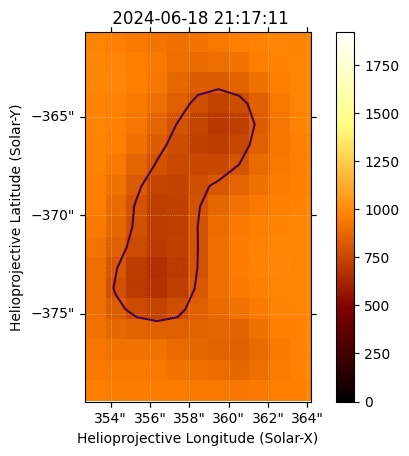

In [18]:
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
#生成的蓝翼图像
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)

fig=plt.figure()
jet_point4=(1515,789)
point4=hawing_map.wcs.pixel_to_world(jet_point4[0],jet_point4[1])
jet_point5=(1525,806)
point5=hawing_map.wcs.pixel_to_world(jet_point5[0],jet_point5[1])
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax3=fig.add_subplot(projection=jet_region)
im=jet_region.plot(axes=ax3,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
cbar=fig.colorbar(im,ax=ax3)
contour=ax3.contour(jet_region.data,levels=[800],transform=ax3.get_transform(jet_region.wcs))

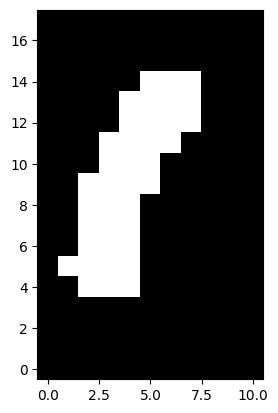

In [19]:
#由contour生成mask
cs = contour
from matplotlib.path import Path
# 初始化 mask
mask = np.zeros_like(jet_region.data, dtype=bool)

# 构造像素坐标网格
ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T  # (N, 2)

# 遍历所有封闭区域
for path in cs.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)
# 现在 mask 就是一个布尔数组，True 表示在等值线包围区域内
plt.figure()
plt.imshow(mask, origin='lower', cmap='gray')
#plt.title("等值线区域 mask")
plt.show()

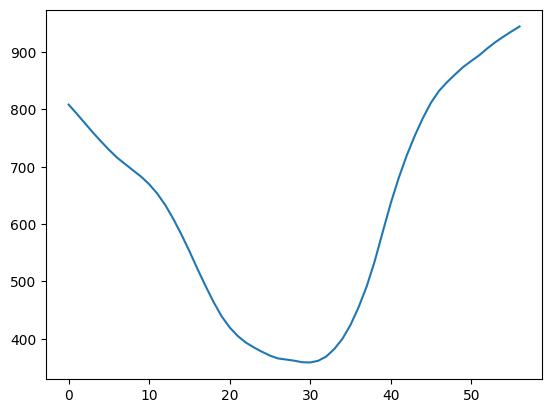

In [20]:
#把mask应用到数据上，得到目标区域的平均光谱曲线
data_jet=rsm[1].data[left_index:right_index,789:807,1515:1526]
data_mask=np.tile(~mask,(right_index-left_index,1,1))
jet_masked=np.ma.array(data_jet,mask=data_mask)
spec_data=jet_masked.mean(axis=(1,2))
plt.plot(spec_data)

DE finished, SSE: 3082.7919501151455
SL=144.089, SU=441.660
tau0L=0.2043, tau0U=0.8166
vL=20.770 km/s, vU=-15.784 km/s
WL=9.3274 km/s, WU=57.2446 km/s
拟合误差: 3837.8844492553617


Text(0.5, 0, 'Wavelength (Angstrom)')

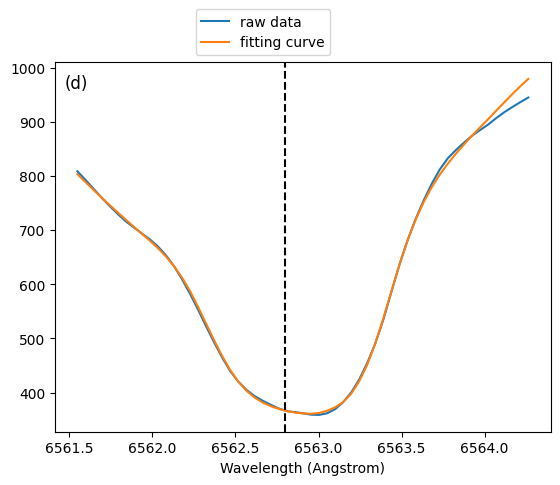

In [21]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)
# 1. wavelength → velocity
lam=lam00[left_index:right_index]#±1.5A
vel = (lam - lam0) / lam0 * c_km  # km/s
I=spec_data
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
# ===== 固定的背景连续谱强度 =====
Icont = I0  # 你之前定义的背景值，例如在平静区域测得的平均值

# 2. 双云模型（去掉 Icont 作为拟合变量）
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

# 3. 残差函数
def residuals(params, vel, I, Icont):
    return double_cloud_vel(params, vel, Icont) - I

# 4. 参数范围
# log tau: [1e-3, 1e2]
# W: [0.05, 200] km/s
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0                       # SL, SU
]
ub = [
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10
]
bounds = list(zip(lb, ub))

# 5. DE全局搜索
def ssq_obj(x):
    res = residuals(x, vel, I, Icont)
    return np.sum(res**2)

result_de = differential_evolution(ssq_obj, bounds, maxiter=800, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, SSE:", result_de.fun)

# 6. 局部精炼
lsq = least_squares(residuals, x_de, args=(vel, I, Icont),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)
x_opt = lsq.x

# 7. 拆解结果
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)


print(f"SL={SL:.3f}, SU={SU:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8. 作图
y_fit = double_cloud_vel(x_opt, vel, Icont)
print('拟合误差:',np.sum((I-y_fit)**2))
fig,ax=plt.subplots()
ax.plot(lam, I, label='raw data')
ax.plot(lam, y_fit, label='fitting curve')
ax.text(0.02,0.93,'(d)',color='black',transform=ax.transAxes,fontsize=12)
ax.axvline(lam0, linestyle='--',color='black')
ax.legend(bbox_to_anchor=(0.27, 1))
ax.set_xlabel('Wavelength (Angstrom)')

In [7]:
np.save('x_opt_long.npy',x_opt)